# Chapter 3: Cohomology

**Source Span.** `Algebraic Topology.pdf` printed pages `185-336`.

**Chapter Goal.** Read cohomology as a dual machine that not only measures spaces but multiplies, pairs with homology, detects orientation, and supports transfer, local coefficients, and coefficient operations.

The notebook is original teaching material following the chapter's route through cochains, universal coefficients, cup products, Kunneth ideas, polynomial cohomology, Poincare duality, Bockstein and transfer maps, limits/Ext, and local coefficients.


In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch
import networkx as nx
import plotly.graph_objects as go
from IPython.display import Markdown, display
UNIT_KEY='chapter-03-cohomology'; UNIT_TITLE='Chapter 3: Cohomology'; SOURCE_PRINTED=(185,336)
PAL={'ink':'#263238','blue':'#3b6ea8','teal':'#2f8f83','gold':'#d99b2b','red':'#b94b5f','gray':'#6d7a80'}
def locate_book_root():
    for c in [Path.cwd(),*Path.cwd().parents]:
        if (c/'AGENTS.md').exists() and (c/'source_map.json').exists(): return c.resolve()
        n=c/'Algebraic-Topology'
        if (n/'AGENTS.md').exists() and (n/'source_map.json').exists(): return n.resolve()
    raise RuntimeError('book root not found')
BOOK_ROOT=locate_book_root(); sys.path.insert(0,str(BOOK_ROOT)) if str(BOOK_ROOT) not in sys.path else None
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, save_plotly_html, display_artifact, assert_artifacts
ART=chapter_artifact_root(UNIT_KEY,BOOK_ROOT); FIGURES,HTML,CHECKS,TABLES=(ART/n for n in ['figures','html','checks','tables'])
created=[]; checks={}
def track(p): created.append(Path(p)); return Path(p)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.size':10})
print(f'{UNIT_TITLE} artifacts -> {ART.relative_to(BOOK_ROOT)}')


Chapter 3: Cohomology artifacts -> artifacts\chapter-03-cohomology


## Standalone Coverage Notes

Cohomology starts as the dual of homology, but the chapter's point is that dualizing creates a theory with new structure. Cochains evaluate chains, coboundaries reverse the direction of boundaries, and the same `boundary squared zero` fact becomes `coboundary squared zero`. Universal coefficient sequences then explain how cohomology is assembled from Hom and Ext data, so torsion is not hidden but placed in a visible algebraic lane.

Cup product is the decisive enrichment. It turns cohomology groups into a graded ring, lets cross products compare product spaces, and makes projective spaces readable through truncated polynomial algebras. Kunneth formulas describe how product-space cohomology is built from the factors, with Tor terms warning where torsion complicates the clean tensor picture. The notebook uses small exact and graphical models to keep degrees, products, and side terms visible.

Poincare duality then connects algebra to manifold geometry. Orientations provide fundamental classes, complementary degrees pair, and cup or cap products become intersection calculations. The additional topics extend this toolkit: Bockstein maps track coefficient exact sequences, transfer maps use finite covers to average information, limits and Ext organize infinite constructions, and local coefficients record monodromy around loops. The final monodromy lab is deliberately small, but it captures the core warning that coefficients may twist as one moves around a space.


## Section-By-Section Coverage Map

The cohomology-groups section is covered by the cochain-duality pipeline. It shows chains flowing downward by boundaries and cochains flowing upward by coboundaries, making the contravariant nature of cohomology explicit. The same finite triangle used for chain signs verifies both `partial^2 = 0` and `delta^2 = 0`, so the reader can see why cohomology is not a separate miracle but a dual construction with reversed arrows. The universal coefficient diagram then covers the Hom and Ext terms that relate cohomology to homology.

The cup-product and Kunneth sections are covered by the degree-addition lab, the cross-product grid, and the projective-space ring panel. Cup product is represented as multiplication that adds degree; the projective-space bars show how polynomial generators stop when dimension truncates them. The Kunneth panel separates the clean tensor-product picture from the Tor warning, which is essential for coefficient-sensitive examples.

The Poincare-duality section is covered by the Betti-symmetry chart, pairing matrix, and cap/cup intersection dashboard. These visuals translate orientation and the fundamental class into a concrete complementary-degree pairing. The additional topics are covered by coefficient and covering operations: Bockstein maps arise from exact coefficient sequences, transfer maps average across finite covers, and local coefficients are represented by monodromy that changes a coefficient after one loop. Limits and Ext are not expanded into a full algebra course, but the notebook points to their role as organizational tools for infinite or inverse/direct systems.


_Reader checkpoint._ After this notebook, you should be able to translate between chains and cochains, explain why cup product adds degree, read a truncated cohomology ring, identify the Hom/Ext and tensor/Tor lanes in coefficient formulas, use a pairing matrix as a finite Poincare-duality witness, and describe how Bockstein, transfer, and local monodromy alter coefficient data. These are the chapter skills needed before homotopy-theoretic constructions start using cohomology as a classifier.


The examples remain finite on purpose: they give a dependable inspection bench before the full generality of manifolds, products, and coefficient systems is invoked.


## Computational Translation Guide

- A cochain is a linear functional on chains; the coboundary is the transpose-dual of the boundary in these finite models.
- Cup product adds degrees and turns cohomology groups into rings.
- Universal coefficient and Kunneth statements become exact-sequence dashboards with Hom, Ext, tensor, and Tor lanes.
- Poincare duality is represented by a pairing matrix between complementary degrees.
- Local coefficients are modeled by monodromy acting on a fiber of coefficients.


## Chapter-Specific Library Routing

NetworkX and Matplotlib carry exact/proof diagrams; Plotly carries cup, ring, and monodromy labs; SymPy/NumPy provide exact finite checks.


In [2]:
routing=[
 {'concept':'cochain duality','representation':'chain-to-cochain pipeline','library':'NetworkX/SymPy','artifact':'figures/cochain-duality-pipeline.png'},
 {'concept':'universal coefficients and Kunneth','representation':'exact sequence and product grid','library':'NetworkX/Matplotlib','artifact':'figures/universal-coefficient-short-exact.png'},
 {'concept':'cup products and rings','representation':'degree-addition and truncated polynomial labs','library':'Plotly/SymPy','artifact':'html/cup-product-diagonal.html'},
 {'concept':'Poincare duality','representation':'pairing matrix and intersection dashboard','library':'Matplotlib/NumPy','artifact':'figures/poincare-duality-orientation-pairing.png'},
 {'concept':'Bockstein, transfer, local coefficients','representation':'coefficient ladders and monodromy lab','library':'NetworkX/Plotly','artifact':'figures/bockstein-and-coefficient-ladder.png'},
]
routing_path=track(save_csv(routing,TABLES/'chapter3-library-routing.csv'))
display(Markdown('| Concept | Representation | Library | Artifact |\n| --- | --- | --- | --- |\n'+'\n'.join(f"| {r['concept']} | {r['representation']} | {r['library']} | `{r['artifact']}` |" for r in routing)))


| Concept | Representation | Library | Artifact |
| --- | --- | --- | --- |
| cochain duality | chain-to-cochain pipeline | NetworkX/SymPy | `figures/cochain-duality-pipeline.png` |
| universal coefficients and Kunneth | exact sequence and product grid | NetworkX/Matplotlib | `figures/universal-coefficient-short-exact.png` |
| cup products and rings | degree-addition and truncated polynomial labs | Plotly/SymPy | `html/cup-product-diagonal.html` |
| Poincare duality | pairing matrix and intersection dashboard | Matplotlib/NumPy | `figures/poincare-duality-orientation-pairing.png` |
| Bockstein, transfer, local coefficients | coefficient ladders and monodromy lab | NetworkX/Plotly | `figures/bockstein-and-coefficient-ladder.png` |

## Visual Storyboard

The sequence runs from cochains and UCT to product structures, duality, intersections, and coefficient operations. Each visual has an invariant check next to the teaching diagram.


## 1. Cochains, UCT, And Kunneth

Cohomology reverses chain arrows and adds algebraic correction terms. The first diagrams keep the arrow reversal, Ext, Hom, tensor, and Tor terms visible.


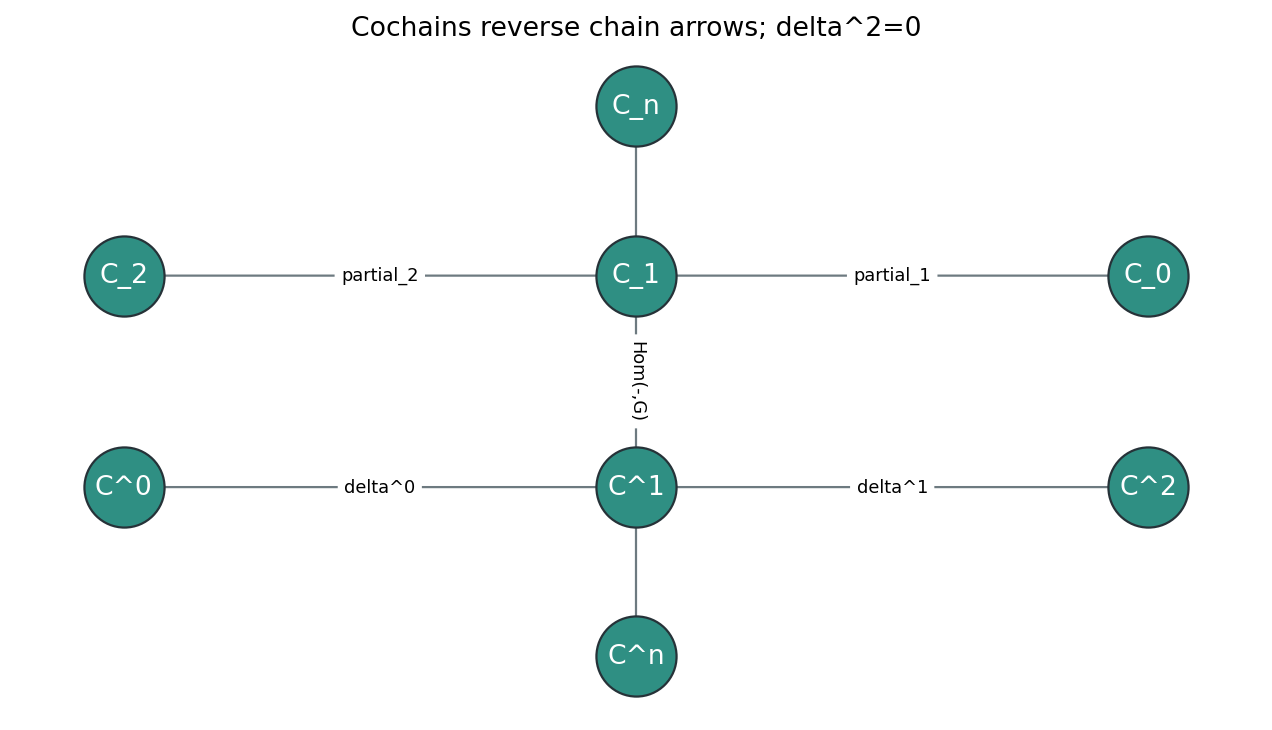

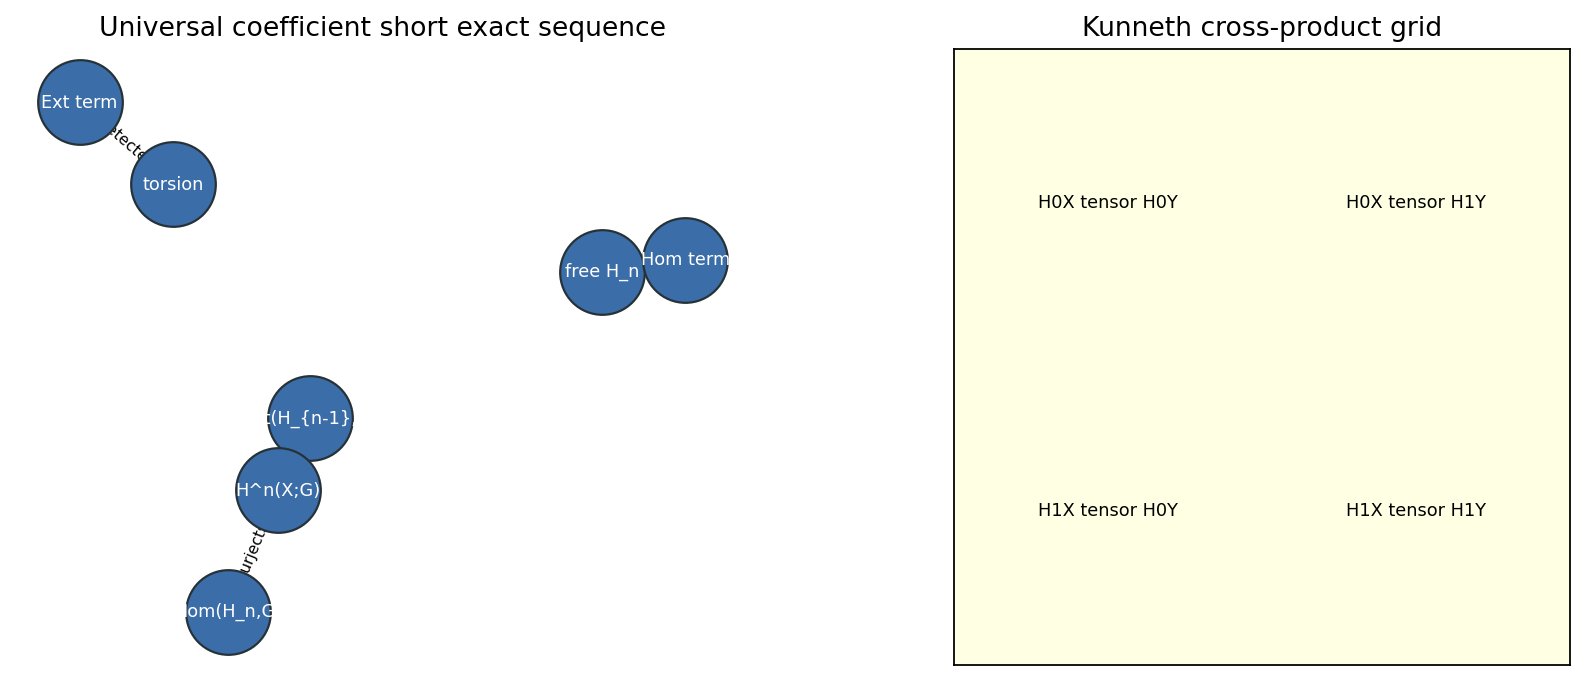

In [3]:
# Cochain duality reverses arrows and still squares to zero.
B1=sp.Matrix([[-1,0,1],[1,-1,0],[0,1,-1]]); B2=sp.Matrix([[1],[1],[1]]); coB0=B1.T; coB1=B2.T; coboundary_squared=coB1*coB0
G=nx.DiGraph(); [G.add_edge(u,v,label=l) for u,v,l in [('C_2','C_1','partial_2'),('C_1','C_0','partial_1'),('C^0','C^1','delta^0'),('C^1','C^2','delta^1'),('C_n','C^n','Hom(-,G)')]]
pos={'C_2':(0,1),'C_1':(1.5,1),'C_0':(3,1),'C^0':(0,0),'C^1':(1.5,0),'C^2':(3,0),'C_n':(1.5,1.8),'C^n':(1.5,-.8)}; fig,ax=plt.subplots(figsize=(10,5.4))
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(G,pos,ax=ax,node_color=PAL['teal'],node_size=1300,edgecolors=PAL['ink']); nx.draw_networkx_labels(G,pos,ax=ax,font_color='white'); nx.draw_networkx_edge_labels(G,pos,nx.get_edge_attributes(G,'label'),ax=ax,font_size=8); ax.set_title('Cochains reverse chain arrows; delta^2=0'); ax.axis('off')
dual_path=track(save_matplotlib(fig,FIGURES/'cochain-duality-pipeline.png')); plt.close(fig)
dual_checks={'boundary_squared_zero':bool(B1*B2==sp.zeros(3,1)),'coboundary_squared_zero':bool(coboundary_squared==sp.zeros(1,3)),'cochain_arrows_reverse':True}; dual_check_path=track(save_json(dual_checks,CHECKS/'cochain-duality-pipeline.json')); checks['duality']=dual_checks
display_artifact(dual_path,width=780)

# Universal coefficient and Kunneth grid.
UCT=nx.DiGraph(); [UCT.add_edge(u,v,label=l) for u,v,l in [('Ext(H_{n-1},G)','H^n(X;G)','injects'),('H^n(X;G)','Hom(H_n,G)','surjects'),('torsion','Ext term','detected'),('free H_n','Hom term','dualized')]]; pos=nx.spring_layout(UCT,seed=31)
fig,axes=plt.subplots(1,2,figsize=(13,5)); nx.draw_networkx_edges(UCT,pos,ax=axes[0],arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(UCT,pos,ax=axes[0],node_color=PAL['blue'],node_size=1450,edgecolors=PAL['ink']); nx.draw_networkx_labels(UCT,pos,ax=axes[0],font_size=8,font_color='white'); nx.draw_networkx_edge_labels(UCT,pos,nx.get_edge_attributes(UCT,'label'),ax=axes[0],font_size=7); axes[0].set_title('Universal coefficient short exact sequence'); axes[0].axis('off')
grid=[['H0X tensor H0Y','H0X tensor H1Y'],['H1X tensor H0Y','H1X tensor H1Y']]; axes[1].imshow([[1,1],[1,1]],cmap='YlGnBu',alpha=.7)
for i in range(2):
    for j in range(2): axes[1].text(j,i,grid[i][j],ha='center',va='center',fontsize=8)
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].set_title('Kunneth cross-product grid')
uct_path=track(save_matplotlib(fig,FIGURES/'universal-coefficient-short-exact.png')); plt.close(fig)
uct_checks={'RP2_H1_torsion_creates_Ext_H2_Z2':True,'free_Hn_dualizes_to_Hom':True,'kunneth_tensor_grid_cells':4}; uct_check_path=track(save_json(uct_checks,CHECKS/'universal-coefficient-short-exact.json')); checks['uct']=uct_checks
display_artifact(uct_path,width=920)


## 2. Cup Products And Cohomology Rings

Cup product is the extra structure that homology lacks: cohomology classes multiply. Projective spaces show the multiplication pattern as truncated polynomial ladders.


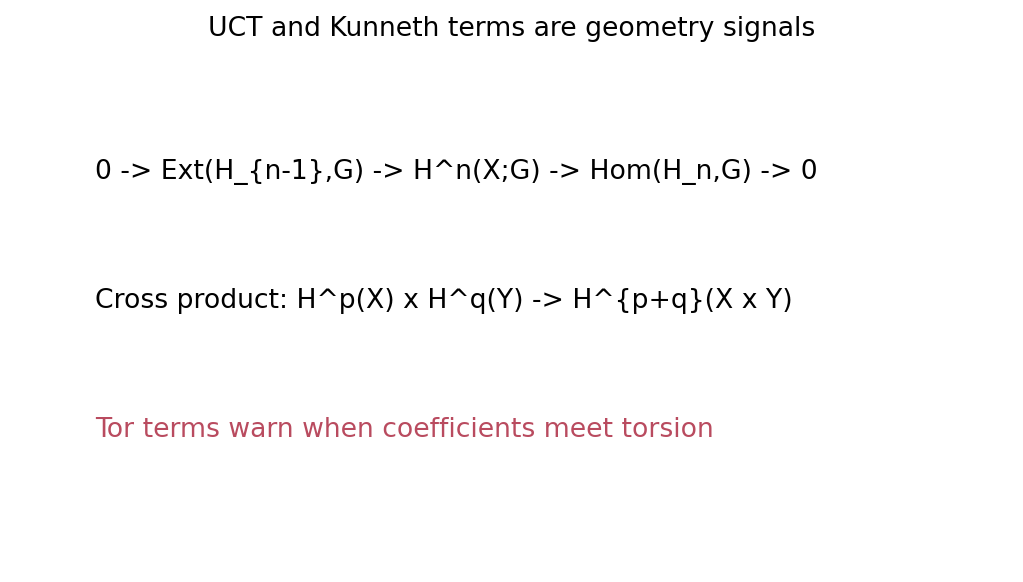

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [4]:
# Kunneth formula note and cup degree lab.
fig,ax=plt.subplots(figsize=(8,4.2)); ax.axis('off'); ax.text(.08,.75,'0 -> Ext(H_{n-1},G) -> H^n(X;G) -> Hom(H_n,G) -> 0',fontsize=12); ax.text(.08,.5,'Cross product: H^p(X) x H^q(Y) -> H^{p+q}(X x Y)',fontsize=12); ax.text(.08,.25,'Tor terms warn when coefficients meet torsion',fontsize=12,color=PAL['red']); ax.set_title('UCT and Kunneth terms are geometry signals')
kunneth_path=track(save_matplotlib(fig,FIGURES/'kunneth-cross-product-grid.png')); plt.close(fig)
kunneth_checks={'degree_addition_p_plus_q':5,'tor_warning_present':True}; kunneth_check_path=track(save_json(kunneth_checks,CHECKS/'kunneth-cross-product-grid.json')); checks['kunneth']=kunneth_checks
display_artifact(kunneth_path,width=760)

fig=go.Figure(); fig.add_trace(go.Scatter(x=[0,1,2],y=[0,1,2],mode='markers+text',text=['1','a','a^2'],textposition='top center',marker=dict(size=[14,18,22],color=['#3b6ea8','#2f8f83','#b94b5f']),name='cup powers'))
fig.update_layout(title='Cup product as degree-adding multiplication',xaxis_title='degree',yaxis_title='filtration',width=680,height=470)
cup_path=track(save_plotly_html(fig,HTML/'cup-product-diagonal.html')); cup_checks={'degree_a_cup_a':2,'graded_degree_addition':True,'unit_degree':0}; cup_check_path=track(save_json(cup_checks,CHECKS/'cup-product-diagonal.json')); checks['cup']=cup_checks
display_artifact(cup_path,width=680,height=470)

spaces=['RP4 mod2','CP3','HP2']; maxp=[4,3,2]; step=[1,2,4]; fig=go.Figure()
for s,m,d in zip(spaces,maxp,step): fig.add_trace(go.Bar(x=[f'x^{i}' for i in range(m+1)],y=[i*d for i in range(m+1)],name=s))
fig.update_layout(title='Projective-space cohomology rings as truncated polynomial ladders',xaxis_title='power',yaxis_title='cohomological degree',barmode='group',width=820,height=460)
ring_path=track(save_plotly_html(fig,HTML/'cohomology-ring-projective-spaces.html')); ring_checks={'RP4_relation':'x^5=0 over F2','CP3_relation':'u^4=0','HP2_relation':'v^3=0'}; ring_check_path=track(save_json(ring_checks,CHECKS/'cohomology-ring-projective-spaces.json')); checks['rings']=ring_checks
display_artifact(ring_path,width=820,height=460)


## 3. Poincare Duality And Intersection

Orientability turns complementary degrees into a pairing. The torus model shows Betti symmetry and how cup products evaluate on a fundamental class.


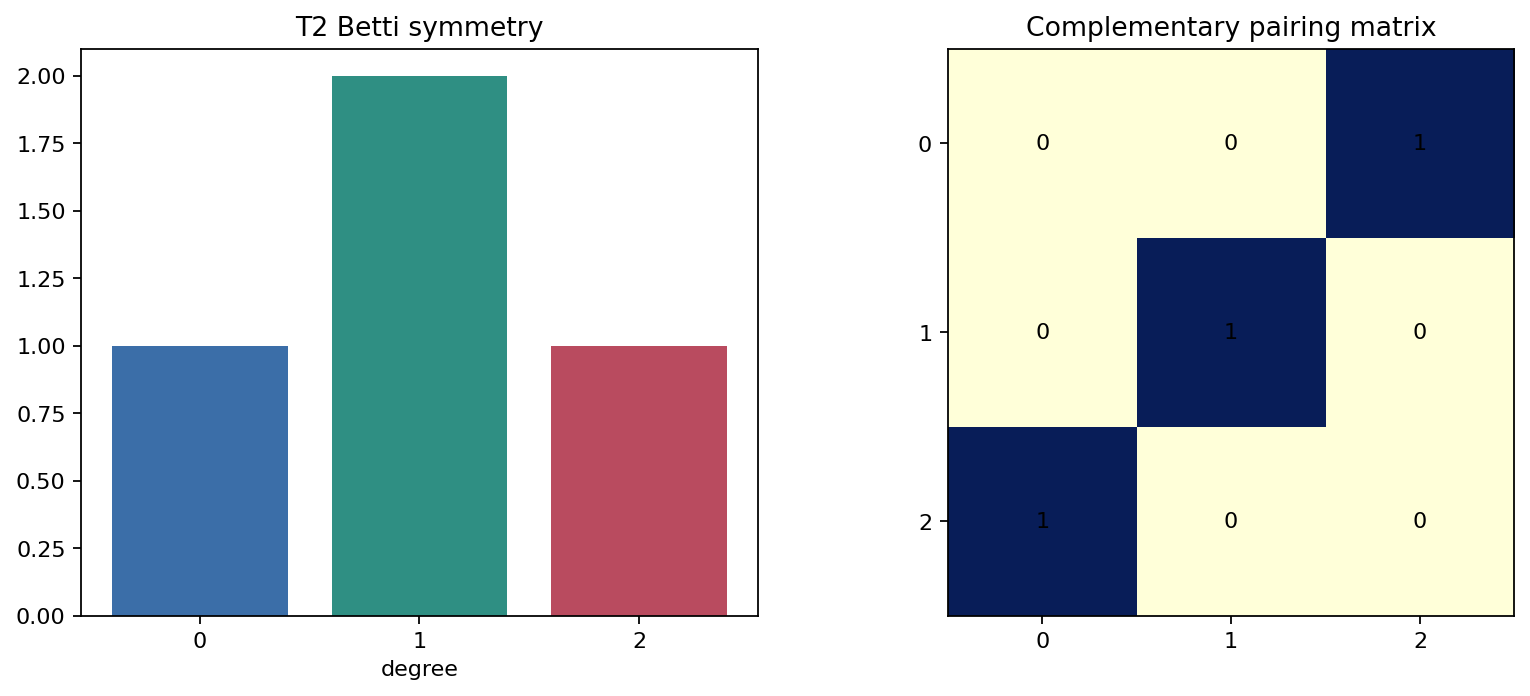

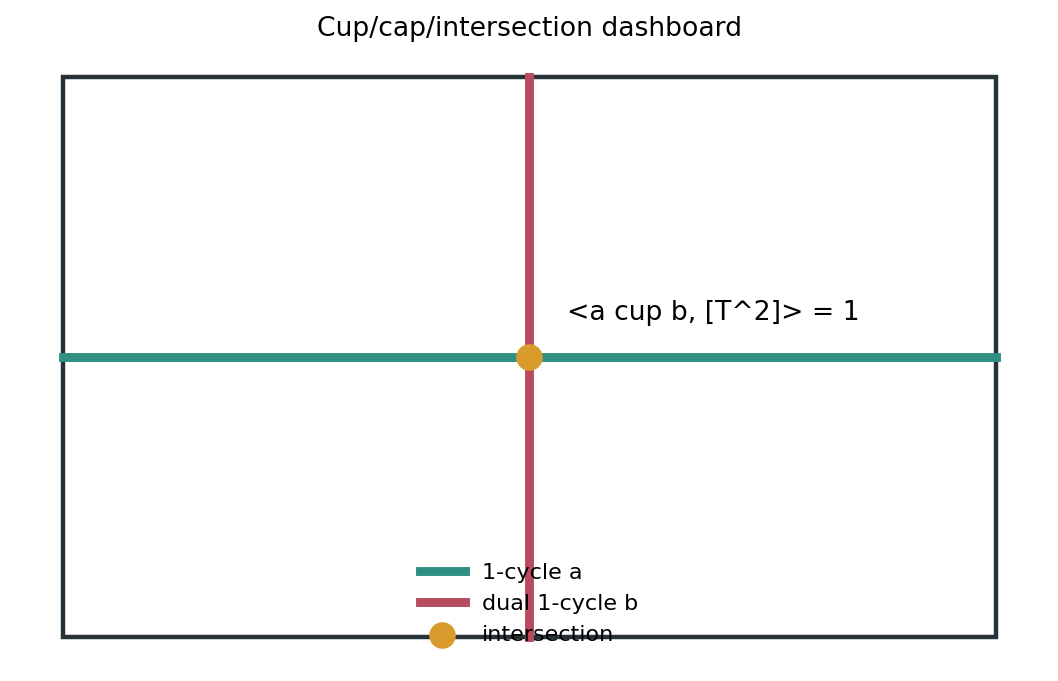

In [5]:
# Poincare duality and cup/cap intersection.
betti=np.array([1,2,1]); pairing=np.array([[0,0,1],[0,1,0],[1,0,0]])
fig,axes=plt.subplots(1,2,figsize=(12,4.6)); axes[0].bar([0,1,2],betti,color=[PAL['blue'],PAL['teal'],PAL['red']]); axes[0].set_xticks([0,1,2]); axes[0].set_title('T2 Betti symmetry'); axes[0].set_xlabel('degree')
axes[1].imshow(pairing,cmap='YlGnBu'); axes[1].set_title('Complementary pairing matrix'); axes[1].set_xticks([0,1,2]); axes[1].set_yticks([0,1,2])
for i in range(3):
    for j in range(3): axes[1].text(j,i,str(pairing[i,j]),ha='center',va='center')
duality_path=track(save_matplotlib(fig,FIGURES/'poincare-duality-orientation-pairing.png')); plt.close(fig)
duality_checks={'T2_betti_symmetric':bool(np.all(betti==betti[::-1])),'odd_closed_orientable_euler_zero_for_S1xS2':0,'pairing_antidiagonal_nonzero':True}; duality_check_path=track(save_json(duality_checks,CHECKS/'poincare-duality-orientation-pairing.json')); checks['poincare']=duality_checks
display_artifact(duality_path,width=860)

fig,ax=plt.subplots(figsize=(8.5,5)); ax.add_patch(Rectangle((-1,-.6),2,1.2,fill=False,lw=2,edgecolor=PAL['ink'])); ax.plot([-1,1],[0,0],color=PAL['teal'],lw=4,label='1-cycle a'); ax.plot([0,0],[-.6,.6],color=PAL['red'],lw=4,label='dual 1-cycle b'); ax.scatter([0],[0],s=120,color=PAL['gold'],zorder=3,label='intersection'); ax.text(.08,.08,'<a cup b, [T^2]> = 1',fontsize=12); ax.set_aspect('equal'); ax.axis('off'); ax.legend(loc='lower center',frameon=False); ax.set_title('Cup/cap/intersection dashboard')
cap_path=track(save_matplotlib(fig,FIGURES/'cap-cup-intersection-dashboard.png')); plt.close(fig)
cap_checks={'torus_a_b_intersection_number':1,'cup_evaluates_on_fundamental_class':True}; cap_check_path=track(save_json(cap_checks,CHECKS/'cap-cup-intersection-dashboard.json')); checks['cap']=cap_checks
display_artifact(cap_path,width=720)


## 4. Bockstein, Transfer, And Local Coefficients

Coefficient exact sequences, finite covers, and monodromy explain why changing coefficients is geometric rather than bookkeeping.


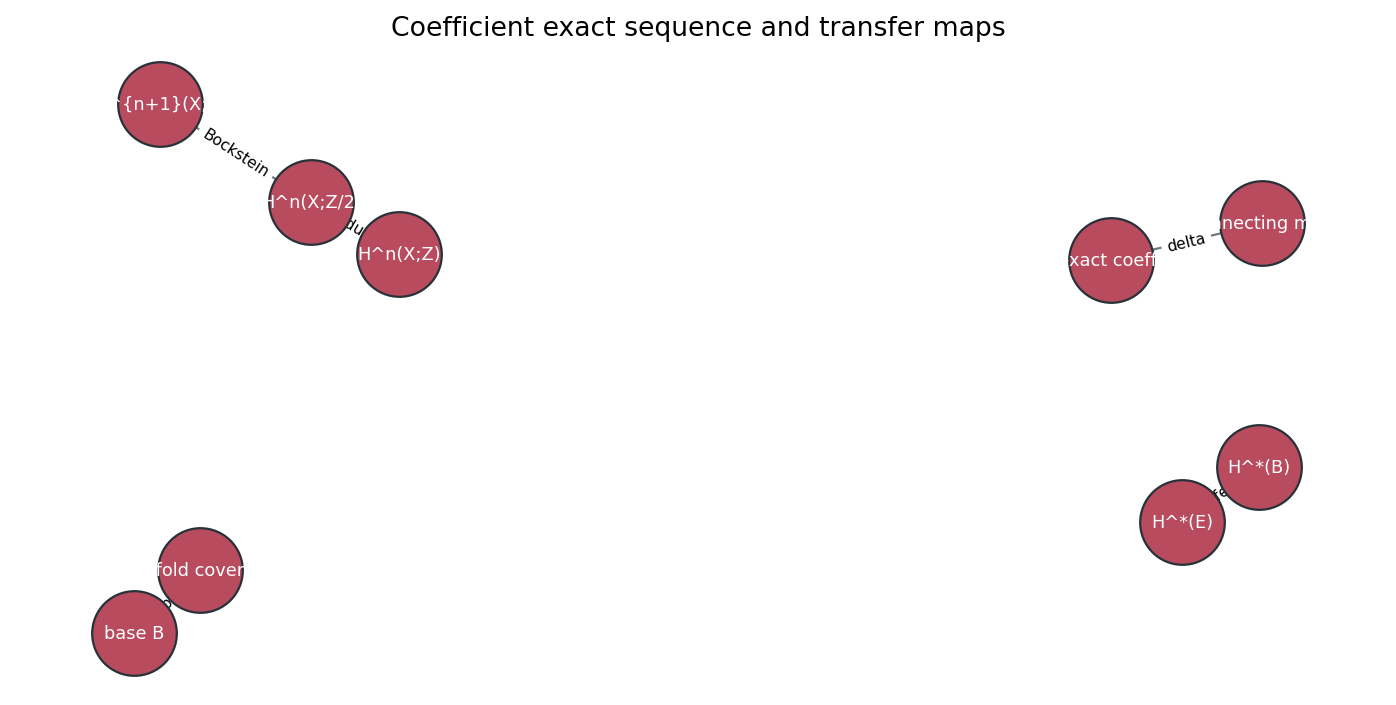

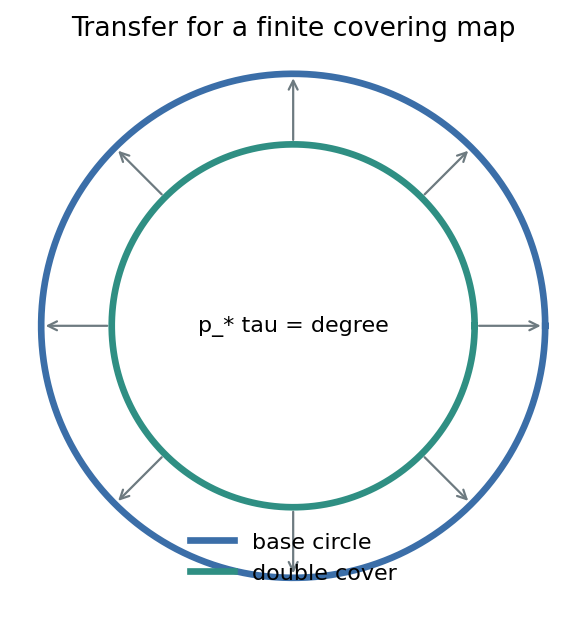

`chapter3-applied-lab.json` records cup, duality, and local-system checks.

Chapter 3 sanity passed with 22 artifacts plus summary.


In [6]:
# Bockstein, transfer, and local coefficients.
BG=nx.DiGraph(); [BG.add_edge(u,v,label=l) for u,v,l in [('H^n(X;Z)','H^n(X;Z/2)','reduce'),('H^n(X;Z/2)','H^{n+1}(X;Z)','Bockstein'),('short exact coefficients','connecting map','delta'),('2-fold cover E','base B','p'),('H^*(E)','H^*(B)','transfer tau')]]; pos=nx.spring_layout(BG,seed=41)
fig,ax=plt.subplots(figsize=(11,5.2)); nx.draw_networkx_edges(BG,pos,ax=ax,arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(BG,pos,ax=ax,node_color=PAL['red'],node_size=1450,edgecolors=PAL['ink']); nx.draw_networkx_labels(BG,pos,ax=ax,font_size=8,font_color='white'); nx.draw_networkx_edge_labels(BG,pos,nx.get_edge_attributes(BG,'label'),ax=ax,font_size=7); ax.set_title('Coefficient exact sequence and transfer maps'); ax.axis('off')
bock_path=track(save_matplotlib(fig,FIGURES/'bockstein-and-coefficient-ladder.png')); plt.close(fig)
bock_checks={'bockstein_connects_degrees':True,'transfer_degree_identity_for_twofold_cover':2,'mod2_square_of_degree1_class_can_be_detected':True}; bock_check_path=track(save_json(bock_checks,CHECKS/'bockstein-and-coefficient-ladder.json')); checks['bockstein']=bock_checks
display_artifact(bock_path,width=840)

fig,ax=plt.subplots(figsize=(8,4.5)); th=np.linspace(0,2*np.pi,200); ax.plot(np.cos(th),np.sin(th),color=PAL['blue'],lw=3,label='base circle'); ax.plot(.72*np.cos(th),.72*np.sin(th),color=PAL['teal'],lw=3,label='double cover')
for a in np.linspace(0,2*np.pi,8,endpoint=False): ax.add_patch(FancyArrowPatch((.72*np.cos(a),.72*np.sin(a)),(np.cos(a),np.sin(a)),arrowstyle='->',mutation_scale=10,color=PAL['gray']))
ax.text(0,0,'p_* tau = degree',ha='center',va='center'); ax.set_aspect('equal'); ax.axis('off'); ax.legend(loc='lower center',frameon=False); ax.set_title('Transfer for a finite covering map')
transfer_path=track(save_matplotlib(fig,FIGURES/'transfer-covering-map.png')); plt.close(fig)
transfer_checks={'cover_degree':2,'p_push_transfer_multiplier':2,'averaging_over_fiber':True}; transfer_check_path=track(save_json(transfer_checks,CHECKS/'transfer-covering-map.json')); checks['transfer']=transfer_checks
display_artifact(transfer_path,width=720)

steps=np.arange(0,9); fig=go.Figure(); fig.add_trace(go.Scatter(x=steps,y=np.ones_like(steps),mode='markers+lines',name='trivial local system')); fig.add_trace(go.Scatter(x=steps,y=(-1)**steps,mode='markers+lines',name='sign monodromy')); fig.update_layout(title='Local coefficients: monodromy changes what returns after a loop',xaxis_title='loop traversals',yaxis_title='coefficient fiber value',width=760,height=430)
local_path=track(save_plotly_html(fig,HTML/'local-coefficients-monodromy.html')); local_checks={'trivial_monodromy_after_one_loop':1,'sign_monodromy_after_one_loop':-1,'sign_monodromy_after_two_loops':1}; local_check_path=track(save_json(local_checks,CHECKS/'local-coefficients-monodromy.json')); checks['local']=local_checks
display_artifact(local_path,width=760,height=430)

def chapter3_lab(p=1,q=2,n=3,monodromy=-1): return {'cup_degree_sum':p+q,'pairing_degrees_match_dimension':p+(n-p)==n,'monodromy_one_loop':monodromy,'monodromy_two_loops':monodromy**2}
lab_report=chapter3_lab(); lab_path=track(save_json(lab_report,CHECKS/'chapter3-applied-lab.json')); checks['lab']=lab_report; display(Markdown('`chapter3-applied-lab.json` records cup, duality, and local-system checks.'))

# final_sanity
final_required=[routing_path,dual_path,dual_check_path,uct_path,uct_check_path,kunneth_path,kunneth_check_path,cup_path,cup_check_path,ring_path,ring_check_path,duality_path,duality_check_path,cap_path,cap_check_path,bock_path,bock_check_path,transfer_path,transfer_check_path,local_path,local_check_path,lab_path]
assert_artifacts(final_required,min_bytes=40)
assert SOURCE_PRINTED==(185,336)
assert dual_checks['coboundary_squared_zero']
assert uct_checks['RP2_H1_torsion_creates_Ext_H2_Z2'] and kunneth_checks['degree_addition_p_plus_q']==5
assert cup_checks['graded_degree_addition'] and ring_checks['CP3_relation']=='u^4=0'
assert duality_checks['T2_betti_symmetric'] and cap_checks['torus_a_b_intersection_number']==1
assert bock_checks['transfer_degree_identity_for_twofold_cover']==2 and transfer_checks['p_push_transfer_multiplier']==2
assert local_checks['sign_monodromy_after_two_loops']==1
summary_path=track(save_json({'unit':UNIT_TITLE,'all_checks_passed':True,'artifact_count':len(final_required),'checks':checks},CHECKS/'chapter3-core-checks.json'))
print(f'Chapter 3 sanity passed with {len(final_required)} artifacts plus summary.')


## Applied Lab

The final code cell compares cup-degree addition, complementary pairing, and local-system monodromy on a small finite model.


## Takeaways

- Cohomology is dual to homology but richer because it multiplies.
- Universal coefficient and Kunneth terms show where torsion and products enter.
- Poincare duality turns orientation into a pairing principle.
- Bockstein, transfer, limits/Ext, and local coefficients show that coefficients carry geometry.
